## Library import

In [1]:
# --- Standard library ---
from pathlib import Path
import warnings

# --- Core data science ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# --- Global config ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Dataset Load

In [2]:
# --- Path configuration ---
DATA_PATH = Path("../data/raw/enhanced_motor_vehicle_repair_towing_dataset.csv")
SAMPLE_ROWS = 1_000_000  # can be adjusted depending on computer memory availability
df = pd.read_csv(DATA_PATH, low_memory=False) # SAMPLE_ROWS can be added here if needed

### Dataset overview

In [3]:
df.head(2)

,Service ID,Customer Name,Vehicle Type,Make and Model,Service Type,Service Description,Repair Date,Towing Date,Tow Location,Drop-off Location,Mechanic Name,Tow Truck Driver,Parts Used,Total Cost,Payment Method,Warranty Information,Service Status,Customer Feedback,Follow-up Needed,Urgency Level,Customer Type,Service Duration Hours,Estimated Cost,Mileage at Service,Insurance Claim Used,Technician Rating,Tow Distance Miles,Is Warranty Valid
0,100000,Emily Smith,Bus,BMW School Bus,Oil Change,Diagnosed and repaired Oil Drain Plug.,2022-05-14,NaN,NaN,NaN,Mechanic 2,NaN,"Oil Filter, Oil Drain Plug, Synthetic Oil",77.82,Cash,90 days on labor,In Progress,NaN,Yes,Scheduled,Fleet,3.6,70.5,114248,No,1.9,0.0,Yes
1,100001,David Smith,Truck,Harley-Davidson Ram 1500,Tire Replacement,Diagnosed and repaired Tire.,2020-07-08,NaN,NaN,NaN,Mechanic 13,NaN,"Rim, Tire, TPMS Sensor",135.97,Insurance,6 months on new tire,s,NaN,No,Emergency,Fleet,1.9,125.0,250870,Yes,4.9,0.0,Yes


In [4]:
df.tail(2)

,Service ID,Customer Name,Vehicle Type,Make and Model,Service Type,Service Description,Repair Date,Towing Date,Tow Location,Drop-off Location,Mechanic Name,Tow Truck Driver,Parts Used,Total Cost,Payment Method,Warranty Information,Service Status,Customer Feedback,Follow-up Needed,Urgency Level,Customer Type,Service Duration Hours,Estimated Cost,Mileage at Service,Insurance Claim Used,Technician Rating,Tow Distance Miles,Is Warranty Valid
1999998,2099998,Emily Miller,Truck,Harley-Davidson F-150,Brake Service,Diagnosed and repaired Rotors.,2022-04-06,NaN,NaN,NaN,Mechanic 8,NaN,"Brake Fluid, Brake Pads, Calipers",162.11,Cash,180 days on brake pads,s,NaN,Yes,Standard,Individual,3.2,169.15,42408,No,1.6,0.0,Yes
1999999,2099999,Kimberly Johnson,Van,Yamaha Odyssey,Towing,Diagnosed and repaired no parts used.,2024-04-03,2021-11-25,Highway,Parking Lot,Mechanic 18,Driver 4,No parts used,107.45,Company Invoice,No warranty offered,s,NaN,No,Standard,Individual,2.3,110.62,97183,No,3.2,62.9,No


### Standarize column names (snake_case)

In [5]:
df.columns = (df.columns
              .str.strip() # for espaces
              .str.lower() # lower case
              .str.replace(" ", "_") # insert _
              .str.replace("-", "_")) # replace - for _
df.columns.to_list()

['service_id',
 'customer_name',
 'vehicle_type',
 'make_and_model',
 'service_type',
 'service_description',
 'repair_date',
 'towing_date',
 'tow_location',
 'drop_off_location',
 'mechanic_name',
 'tow_truck_driver',
 'parts_used',
 'total_cost',
 'payment_method',
 'warranty_information',
 'service_status',
 'customer_feedback',
 'follow_up_needed',
 'urgency_level',
 'customer_type',
 'service_duration_hours',
 'estimated_cost',
 'mileage_at_service',
 'insurance_claim_used',
 'technician_rating',
 'tow_distance_miles',
 'is_warranty_valid']

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
service_id,2000000.0,1.100000e+06,577350.413527,100000.0,599999.75,1099999.50,1599999.25,2099999.00
total_cost,2000000.0,3.742204e+02,407.714041,20.0,104.90,198.77,478.95,2797.06
customer_feedback,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_duration_hours,2000000.0,3.028943e+00,1.437699,0.5,2.00,3.00,4.00,10.60
estimated_cost,2000000.0,3.742427e+02,409.037471,18.0,104.71,198.60,478.42,2913.37
mileage_at_service,2000000.0,1.549637e+05,83753.568480,10000.0,82359.00,154973.00,227471.00,300000.00
technician_rating,2000000.0,2.999025e+00,1.155602,1.0,2.00,3.00,4.00,5.00
tow_distance_miles,2000000.0,7.496640e+00,21.084843,0.0,0.00,0.00,0.00,100.00


> Notice that none of the clients has a feedback registered.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 28 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   service_id              int64  
 1   customer_name           object 
 2   vehicle_type            object 
 3   make_and_model          object 
 4   service_type            object 
 5   service_description     object 
 6   repair_date             object 
 7   towing_date             object 
 8   tow_location            object 
 9   drop_off_location       object 
 10  mechanic_name           object 
 11  tow_truck_driver        object 
 12  parts_used              object 
 13  total_cost              float64
 14  payment_method          object 
 15  warranty_information    object 
 16  service_status          object 
 17  customer_feedback       float64
 18  follow_up_needed        object 
 19  urgency_level           object 
 20  customer_type           object 
 21  service_duration_hours  float64

> This data has 2 million entries and 28 variables

#### Missing Values

In [8]:
missing_percentage = df.isnull().sum() / df.shape[0] * 100
missing_percentage

service_id                  0.0000
customer_name               0.0000
vehicle_type                0.0000
make_and_model              0.0000
service_type                0.0000
service_description         0.0000
repair_date                 0.0000
towing_date                85.7131
tow_location               85.7131
drop_off_location          85.7131
mechanic_name               0.0000
tow_truck_driver           85.7131
parts_used                  0.0000
total_cost                  0.0000
payment_method              0.0000
warranty_information        0.0000
service_status              0.0000
customer_feedback         100.0000
follow_up_needed            0.0000
urgency_level               0.0000
customer_type               0.0000
service_duration_hours      0.0000
estimated_cost              0.0000
mileage_at_service          0.0000
insurance_claim_used        0.0000
technician_rating           0.0000
tow_distance_miles          0.0000
is_warranty_valid           0.0000
dtype: float64

> Drop unnecessary cols and high percentage missing data cols

In [9]:
df = df.drop(["service_id", 
              "customer_name", 
              "towing_date", 
              "tow_location", 
              "drop_off_location", 
              "tow_truck_driver", 
              "customer_feedback", 
              "technician_rating", 
              "payment_method", 
              "warranty_information", 
              "is_warranty_valid", 
              "insurance_claim_used",
              "estimated_cost", 
              "mechanic_name"], axis=1)

In [10]:
df.columns.value_counts()

vehicle_type              1
make_and_model            1
service_type              1
service_description       1
repair_date               1
parts_used                1
total_cost                1
service_status            1
follow_up_needed          1
urgency_level             1
customer_type             1
service_duration_hours    1
mileage_at_service        1
tow_distance_miles        1
Name: count, dtype: int64

> We keep 16 cols with related info for service cost calculation

In [11]:
df["vehicle_type"].value_counts()

vehicle_type
Van           334078
SUV           333522
Bus           333269
Truck         333230
Car           332956
Motorcycle    332945
Name: count, dtype: int64

In [12]:
df['make_and_model'].value_counts()

make_and_model
Toyota Coach             21083
Toyota School Bus        21067
Harley-Davidson Coach    21055
Yamaha Coach             20921
Yamaha School Bus        20890
                         ...  
Honda Civic               8215
Yamaha Camry              8174
Yamaha Civic              8168
Toyota Civic              8161
Chevrolet Corolla         8153
Name: count, Length: 176, dtype: int64

In [13]:
df["fabricant"] = df["make_and_model"].str.split().str[0] # to separate and keep vehicle manufacturer
df["fabricant"].value_counts()

fabricant
Dodge              250790
Chevrolet          250746
Toyota             250640
Harley-Davidson    250185
BMW                249679
Honda              249667
Yamaha             249148
Ford               249145
Name: count, dtype: int64

In [14]:
df["service_type"].value_counts(), df["service_type"].nunique()

(service_type
 Oil Change             286316
 Engine Repair          285929
 Battery Replacement    285923
 Tire Replacement       285837
 Towing                 285738
 Transmission Repair    285692
 Brake Service          284565
 Name: count, dtype: int64,
 7)

In [15]:
df['parts_used'].value_counts()

parts_used
No parts used                                   285738
Oil Filter, Synthetic Oil, Oil Drain Plug        48100
Gearbox Seal, Clutch Kit, Transmission Fluid     47942
Transmission Fluid, Clutch Kit, Gearbox Seal     47842
Battery, Battery Terminal, Battery Holder        47833
                                                 ...  
Timing Belt, Engine Mount, Oil Pump              11754
Rotors, Brake Pads, Calipers                     11745
Engine Mount, Timing Belt, Spark Plugs           11706
Calipers, Rotors, Brake Fluid                    11653
Brake Fluid, Calipers, Brake Pads                11621
Name: count, Length: 91, dtype: int64

In [16]:
df["parts_used_normalized"] = (df["parts_used"].dropna().apply(lambda x: ", ".join(sorted([p.strip() for p in str(x).split(",")]))))

In [17]:
df["parts_used_normalized"].value_counts() # recount

parts_used_normalized
Oil Drain Plug, Oil Filter, Synthetic Oil       286316
Battery, Battery Holder, Battery Terminal       285923
No parts used                                   285738
Clutch Kit, Gearbox Seal, Transmission Fluid    285692
Rim, TPMS Sensor, Tire                           71621
Engine Mount, Oil Pump, Spark Plugs              71615
TPMS Sensor, Tire, Valve Stem                    71561
Oil Pump, Spark Plugs, Timing Belt               71527
Engine Mount, Spark Plugs, Timing Belt           71490
Rim, Tire, Valve Stem                            71450
Brake Fluid, Brake Pads, Rotors                  71304
Engine Mount, Oil Pump, Timing Belt              71297
Brake Pads, Calipers, Rotors                     71245
Rim, TPMS Sensor, Valve Stem                     71205
Brake Fluid, Brake Pads, Calipers                71100
Brake Fluid, Calipers, Rotors                    70916
Name: count, dtype: int64

In [18]:
df["parts_used_normalized"].nunique()

16

> Notice that 91 combinations of parts does not mean that they were different, we´ve sorted them and found out that the dataset has only 16 unique parts combinations.

> We will consider parts_used_normalized as a feature with 16 categories. Wich we´ll code to analyze how it affects total cost predictions.

In [19]:
df["service_description"].value_counts(), df["service_description"].nunique()

(service_description
 Diagnosed and repaired no parts used.         285738
 Diagnosed and repaired Oil Filter.             95700
 Diagnosed and repaired Synthetic Oil.          95633
 Diagnosed and repaired Battery.                95626
 Diagnosed and repaired Transmission Fluid.     95406
 Diagnosed and repaired Clutch Kit.             95379
 Diagnosed and repaired Battery Terminal.       95324
 Diagnosed and repaired Oil Drain Plug.         94983
 Diagnosed and repaired Battery Holder.         94973
 Diagnosed and repaired Gearbox Seal.           94907
 Diagnosed and repaired Oil Pump.               71688
 Diagnosed and repaired Rim.                    71603
 Diagnosed and repaired TPMS Sensor.            71521
 Diagnosed and repaired Valve Stem.             71490
 Diagnosed and repaired Timing Belt.            71478
 Diagnosed and repaired Spark Plugs.            71450
 Diagnosed and repaired Engine Mount.           71313
 Diagnosed and repaired Rotors.                 71312
 Diagno

In [ ]:
# Remove "diagnosed and repaired" from all rows
df["service_description"] = ( df["service_description"].str.replace("diagnosed and repaired", 
                                                                    "", case=False).str.strip())  # to eliminate spaces

df["service_description"].value_counts()

service_description
no parts used.         285738
Oil Filter.             95700
Synthetic Oil.          95633
Battery.                95626
Transmission Fluid.     95406
Clutch Kit.             95379
Battery Terminal.       95324
Oil Drain Plug.         94983
Battery Holder.         94973
Gearbox Seal.           94907
Oil Pump.               71688
Rim.                    71603
TPMS Sensor.            71521
Valve Stem.             71490
Timing Belt.            71478
Spark Plugs.            71450
Engine Mount.           71313
Rotors.                 71312
Tire.                   71223
Calipers.               71211
Brake Pads.             71208
Brake Fluid.            70834
Name: count, dtype: int64

In [21]:
df["follow_up_needed"].value_counts()

follow_up_needed
No     1000083
Yes     999917
Name: count, dtype: int64

#### Duplicated data inspection

In [22]:
df.duplicated().value_counts()

False    2000000
Name: count, dtype: int64

> No duplicated rows or data.

In [23]:
df["urgency_level"].value_counts()

urgency_level
Standard     667288
Scheduled    666450
Emergency    666262
Name: count, dtype: int64

In [24]:
if "Tow Distance Miles" in df.columns: 
    df["Needs Tow"] = (df["Tow Distance Miles"].fillna(0) > 0).astype(int)

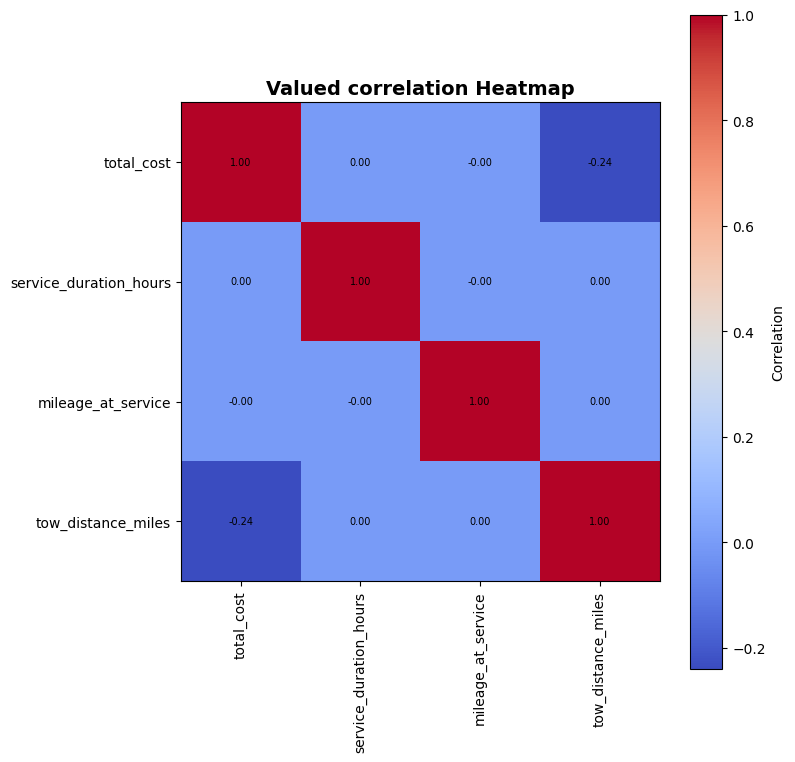

In [25]:
num_df = df.select_dtypes(include=["number"]) # Select only numeric columns
correlation = num_df.corr()

plt.figure(figsize=(8, 8))
im = plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar(im, label="Correlation") # Add colorbar

# Axis labels
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.index)), correlation.index)

for i in range(len(correlation.index)): # --- Add correlation values ---
    for j in range(len(correlation.columns)):
        value = correlation.iloc[i, j]
        plt.text( j, i, f"{value:.2f}",
                 ha="center", va="center",
                 color="black", fontsize=7)

plt.title("Valued correlation Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


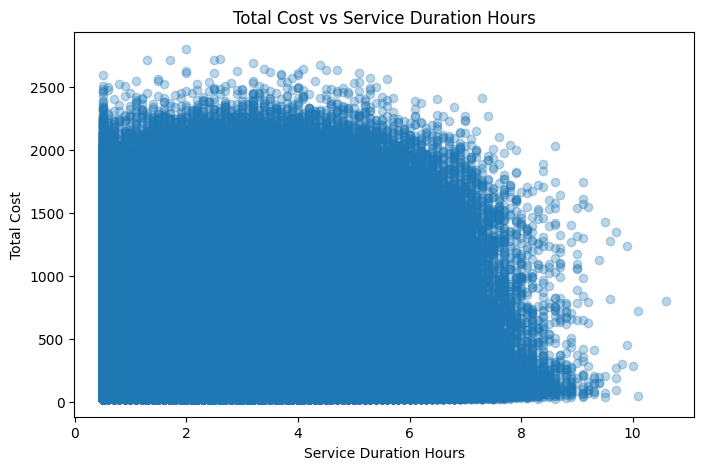

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(df["service_duration_hours"], df["total_cost"], alpha=0.3)
plt.title("Total Cost vs Service Duration Hours")
plt.xlabel("Service Duration Hours")
plt.ylabel("Total Cost")
plt.show()

> Analyzing behaviour between Total cost and Service duration hours we confirm that there is no direct relation. Need to explore correlation with other features.

<Figure size 1200x600 with 0 Axes>

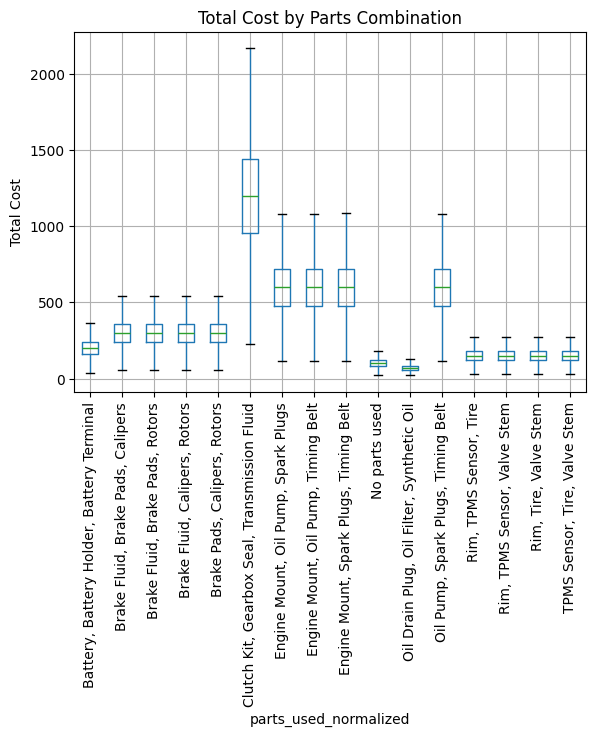

In [27]:
plt.figure(figsize=(12, 6))
df.boxplot(column="total_cost", by="parts_used_normalized", showfliers=False)
plt.xticks(rotation=90)
plt.title("Total Cost by Parts Combination")
plt.suptitle("")  # remove automatic title
plt.ylabel("Total Cost")
plt.show()

> parts_used_normalized affects directly to total cost.

<Figure size 1200x1200 with 0 Axes>

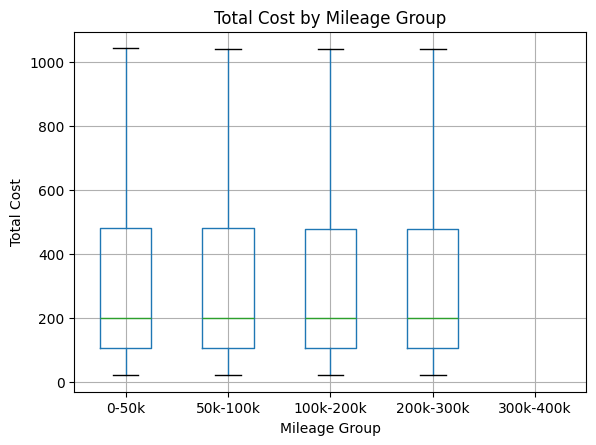

mileage_bin
0-50k        375.495201
50k-100k     374.061315
100k-200k    373.874664
200k-300k    374.134250
300k-400k           NaN
Name: total_cost, dtype: float64


In [28]:
# Define mileage bins (you can adjust if needed)
bins = [0, 50000, 100000, 200000, 300000, 400000]
labels = ["0-50k", "50k-100k", "100k-200k", "200k-300k", "300k-400k"]

# Create a new column with mileage groups
df["mileage_bin"] = pd.cut(df["mileage_at_service"], bins=bins, labels=labels, include_lowest=True)

# Boxplot of cost per mileage bin
plt.figure(figsize=(12, 12))
df.boxplot(column="total_cost", by="mileage_bin", showfliers=False)
plt.title("Total Cost by Mileage Group")
plt.suptitle("")  # remove automatic title
plt.xlabel("Mileage Group")
plt.ylabel("Total Cost")
plt.show()

# Mean costs per group (quick check)
print(df.groupby("mileage_bin")["total_cost"].mean())

> Mileage has low impact on total cost. As a sinthetic dataset.

<Figure size 800x500 with 0 Axes>

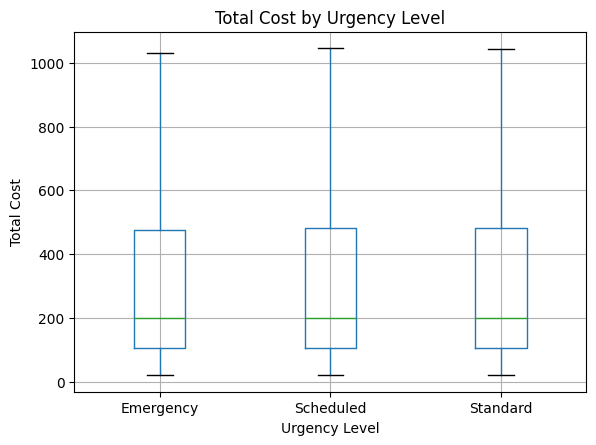

Average cost per urgency level:
urgency_level
Emergency    373.221825
Scheduled    374.788790
Standard     374.649804
Name: total_cost, dtype: float64


In [29]:
plt.figure(figsize=(8, 5))
df.boxplot(column="total_cost", by="urgency_level", showfliers=False)
plt.title("Total Cost by Urgency Level")
plt.suptitle("")  # remove automatic title
plt.xlabel("Urgency Level")
plt.ylabel("Total Cost")
plt.show()

# Mean costs per level
print("Average cost per urgency level:")
print(df.groupby("urgency_level")["total_cost"].mean())

#### Service type analysis

In [30]:
df.groupby("service_type")[["service_duration_hours", "total_cost"]].mean()

,service_duration_hours,total_cost
service_type,,
Battery Replacement,3.029002,200.065037
Brake Service,3.023128,299.880169
Engine Repair,3.031245,599.912074
Oil Change,3.028797,70.093764
Tire Replacement,3.025097,150.220724
Towing,3.032856,100.083687
Transmission Repair,3.032451,1199.769864


<Axes: xlabel='service_type', ylabel='total_cost'>

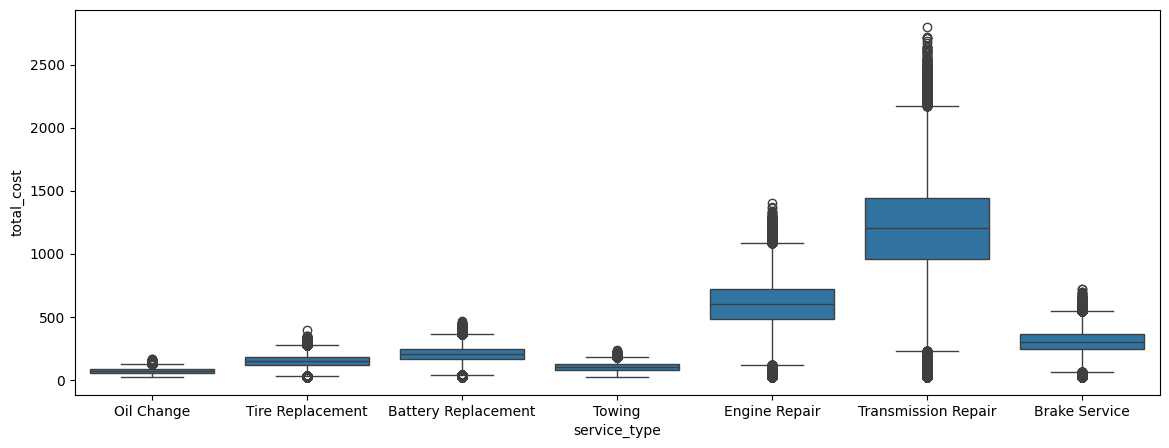

In [31]:
plt.figure(figsize=(14, 5))
sns.boxplot(x="service_type", y="total_cost", data=df)

In [32]:
for service, group in df.groupby("service_type"):
    corr = group["service_duration_hours"].corr(group["total_cost"])
    print(service, corr)

Battery Replacement -0.002534103044233529
Brake Service 0.0006509973653124825
Engine Repair 0.002015495315431197
Oil Change 0.0011374377706429514
Tire Replacement -0.0013305021115531178
Towing -0.0001261153983171364
Transmission Repair 0.0014215483888311872


> We find that correlations percentages between service timmings and total cost are under 1%

In [39]:
df.columns

Index(['vehicle_type', 'make_and_model', 'service_type', 'service_description', 'repair_date', 'parts_used',
       'total_cost', 'service_status', 'follow_up_needed', 'urgency_level', 'customer_type', 'service_duration_hours',
       'mileage_at_service', 'tow_distance_miles', 'fabricant', 'parts_used_normalized', 'mileage_bin'],
      dtype='object')

In [40]:
TARGET = "total_cost" # Define target column
DROP_COLS = [ "make_and_model",
             "mileage_at_service",
             "parts_used",
             "mileage_bin"]

# Keep only columns that exist
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# --- 3. Create modeling dataframe ---
df_model = df.drop(columns=DROP_COLS)

df_model = df # Creates a modeling dataframe

X = df_model.drop(columns=[TARGET]) # Separates features and target
y = df_model[TARGET]

X.shape

(2000000, 16)

In [37]:
y.shape

(2000000,)

In [38]:
X.head(3)

,vehicle_type,make_and_model,service_type,service_description,repair_date,parts_used,service_status,follow_up_needed,urgency_level,customer_type,service_duration_hours,mileage_at_service,tow_distance_miles,fabricant,parts_used_normalized,mileage_bin
0,Bus,BMW School Bus,Oil Change,Oil Drain Plug.,2022-05-14,"Oil Filter, Oil Drain Plug, Synthetic Oil",In Progress,Yes,Scheduled,Fleet,3.6,114248,0.0,BMW,"Oil Drain Plug, Oil Filter, Synthetic Oil",100k-200k
1,Truck,Harley-Davidson Ram 1500,Tire Replacement,Tire.,2020-07-08,"Rim, Tire, TPMS Sensor",s,No,Emergency,Fleet,1.9,250870,0.0,Harley-Davidson,"Rim, TPMS Sensor, Tire",200k-300k
2,Van,BMW Odyssey,Battery Replacement,Battery.,2023-09-16,"Battery Terminal, Battery, Battery Holder",s,Yes,Standard,Business,3.9,155738,0.0,BMW,"Battery, Battery Holder, Battery Terminal",100k-200k
